**Data Loading and Initial Exploration**
-------------------------------------------------------------------------------------------------------------------------------------

In [189]:
import pandas as pd
import numpy as np

In [190]:
df = pd.read_csv("diabetic_data.csv")

In [191]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [192]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

Missing Value Detection
-------------------------------------------------------------------------------------------------------------------------------------

In [193]:
df.isnull().sum()

encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [194]:
df.isin(['?']).sum()

encounter_id                    0
patient_nbr                     0
race                         2273
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum                   0
A1Cresult                       0
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

The "isnull()" function doesn't show missing values because the unknown data in the "weight" column is filled with the "?" symbol. Since this '?' symbol provides no information, I am using "df.isin(['?']).sum()" to check how many hidden missing values there are. I checked the "weight" column as an example, but I noticed that the same situation applies to some other columns as well.

-------------------------------------------------------------------------------------------------------------------------------------
"isnull()" funksiyası, "weight" sütununda çəkisi bilinməyən pasientlərin məlumatları "?" simvolu ilə doldurulduğundan, boş dəyər göstərmir. Lakin, bu "?" simvolu bizə heç bir məlumat vermədiyindən, "df.isin(['?']).sum()" istifadə edərək neçə gizli boş dəyər olduğunu yoxlayıram. "weight" sütununa nümunə kimi baxdım, amma eynizamanda digər bəzi sütunda da eyni vəziyyətin olduğunu gördüm.

Column Cleaning (Drop & Fill)
-------------------------------------------------------------------------------------------------------------------------------------

In [195]:
df = df.drop(columns=['encounter_id'])

In [196]:
df = df.drop(columns=['weight'])

In [197]:
df = df.drop(columns=['payer_code'])

In [198]:
df = df.drop(columns=['race'])

In [199]:
df['diag_1'] = df['diag_1'].replace('?', 'Unknown')
df['diag_2'] = df['diag_2'].replace('?', 'Unknown')
df['diag_3'] = df['diag_3'].replace('?', 'Unknown')

In [200]:
df['medical_specialty'] = df['medical_specialty'].replace('?', 'Unknown')

As a result, the "weight" (high missing rate) and "payer_code" (low clinical relevance) columns were dropped. The sensitive "race" column was removed to avoid model bias. Although they contain some missing data, "diag_1", "diag_2", "diag_3", and "medical_specialty" were kept due to their clinical value, with missing values imputed as 'Unknown'.

-------------------------------------------------------------------------------------------------------------------------------------
Nəticəyə əsasən, boşluq faizi çox yüksək olan "weight" və klinik əhəmiyyəti az olan "payer_code" sütunları tamamilə silindi. Sensitiv məlumat daşıyan "race" sütunu, modelin qərəzli nəticələr verməsinin qarşısını almaq üçün əvvəlcədən çıxarıldı. Boşluq faizi aşağı olan, amma klinik cəhətdən dəyərli ola biləcək "diag_1", "diag_2", "diag_3" və "medical_specialty" sütunları saxlanıldı, boş dəyərlər isə "Unknown" kateqoriyası ilə əvəz olundu.

Leakage Check: Discharge Disposition (Death/Hospice)
-------------------------------------------------------------------------------------------------------------------------------------

In [201]:
df['discharge_disposition_id'].value_counts()

discharge_disposition_id
1     60234
3     13954
6     12902
18     3691
2      2128
22     1993
11     1642
5      1184
25      989
4       815
7       623
23      412
13      399
14      372
28      139
8       108
15       63
24       48
9        21
17       14
16       11
19        8
10        6
27        5
12        3
20        2
Name: count, dtype: int64

In [202]:
death_hospice_codes = [11, 13, 14, 19, 20]
df = df[~df['discharge_disposition_id'].isin(death_hospice_codes)]
print("Number of lines remaining:", len(df))

Number of lines remaining: 99343


The "discharge_disposition_id" column provides information on how a patient was discharged from the hospital. Details about these codes can be found in the "IDS_mapping.csv" file, which is located alongside the data in the downloaded zip folder. Alternatively, they can be viewed in the repository section of the data link. The objective for this dataset is to predict the probability of patient readmission after 30 days. In reality, deceased patients cannot return; therefore, we remove these records (codes 11, 13, 14, 19, 20 - Expired and Hospice cases).

-------------------------------------------------------------------------------------------------------------------------------------
"discharge_disposition_id" sütunu bizə, pasientin xəstxanadan necə çıxdığı haqda məlumat verir. Bu kodlar haqqında məlumatı, "IDS_mapping.csv" faylından əldə edə bilərik. Zip şəklində yüklənən qovluqda data ilə birlikdə yerləşir. Eyni zamanda, linkdən datanın repository hissəsindən də görə bilərik. Datada qarşıya qoyulan məqsəd, pasientlətin 30 gün sonra gəlmə ehtimalı bilməkdir. Real olaraq, vəfat edən pasientlər gələ bilməz və buna görə biz bunları (kod 11, 13, 14, 19, 20 - Expired və Hospice halları) silirik.

Leakage Check: Patient Duplicates
-------------------------------------------------------------------------------------------------------------------------------------

In [203]:
print("Total number of rows:", len(df))
print("Number of unique patients:", df['patient_nbr'].nunique())
print("Number of duplicate rows:", df['patient_nbr'].duplicated().sum())

Total number of rows: 99343
Number of unique patients: 69990
Number of duplicate rows: 29353


The dataset contains 99343 admissions but only 69990 unique patients, meaning 29353 rows are repeated admissions. We keep these rows since each represents a valid, unique clinical event (dates, diagnoses, treatments). However, this introduces a strict data leakage risk, a random "train/test" split could place different records of the same patient into both sets, inflating model performance artificially. To avoid this, we will use a patient-level split based on "patient_nbr" so that all records of a single patient are kept exclusively in either the "train" or "test" set.

-------------------------------------------------------------------------------------------------------------------------------------
Çıxan nəticəyə görə, datasetdə 99343 pasient qəbulu qeydə alınıb, lakin bunlara aid yalnız 69990 unikal xəstə mövcuddur. Bu o deməkdir ki, 29353 sətir eyni xəstələrin fərqli vaxtlarda etdiyi təkrar qəbullara aiddir. Bu sətirlər silinmir, çünki hər biri fərqli bir klinik hadisəni (fərqli tarix, diaqnoz, müalicə) əks etdirir və məlumat baxımından etibarlıdır. Lakin, bu vəziyyət ciddi bir data sızması (data leakage) riski yaradır. Əgər data təsadüfi şəkildə "train/test" hissələrinə bölünərsə, eyni xəstənin fərqli qəbulları hər iki hissəyə düşə bilər və model artıq "tanıdığı" xəstə üzərində test olunmuş kimi süni şəkildə yüksək performans göstərə bilər. Bunun qarşısını almaq üçün data bölgüsü zamanı "patient_nbr" əsasında qruplaşdırma (patient-level split) tətbiq ediləcək ki, eyni xəstəyə aid bütün sətirlər ya tam "train", ya da tam "test" hissəsində qalsın.

Data Quality Check (describe & unique values)
-------------------------------------------------------------------------------------------------------------------------------------

In [204]:
df.describe()

,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,9.934300e+04,99343.000000,99343.000000,99343.000000,99343.000000,99343.000000,99343.000000,99343.000000,99343.000000,99343.000000,99343.000000,99343.000000
mean,5.426117e+07,2.030259,3.517882,5.731083,4.379332,42.906929,1.334236,15.979062,0.369246,0.198444,0.630935,7.401709
std,3.873426e+07,1.446373,5.184359,4.065029,2.968409,19.610032,1.702786,8.094909,1.265142,0.937734,1.260428,1.941013
min,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,2.338675e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,4.541774e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,8.756007e+07,3.000000,3.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


Heç bir açıq-aşkar səhv (mənfi ədəd, məntiqsiz min/max) yoxdur. Bəzi sütunlarda (number_emergency, number_inpatient) kənar dəyərlər var, amma bunlar klinik olaraq mümkündür (xroniki xəstələrdə), ona görə silmirik. Sadəcə qeyd edirik ki, bu dəyişənlər "skewed" paylanmaya malikdir.

Feature Cleaning: Gender & Age
-------------------------------------------------------------------------------------------------------------------------------------

In [205]:
df['gender'].unique()

array(['Female', 'Male', 'Unknown/Invalid'], dtype=object)

In [206]:
df['gender'].value_counts()

gender
Female             53454
Male               45886
Unknown/Invalid        3
Name: count, dtype: int64

In [207]:
df = df[df['gender'] != 'Unknown/Invalid']

In [208]:
df['age'].unique()

array(['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)', '[50-60)',
       '[60-70)', '[70-80)', '[80-90)', '[90-100)'], dtype=object)

In [209]:
age_mapping = {'[0-10)': 5, '[10-20)': 15, '[20-30)': 25, '[30-40)': 35,
    '[40-50)': 45, '[50-60)': 55, '[60-70)': 65, '[70-80)': 75,
    '[80-90)': 85, '[90-100)': 95 }
df['age'] = df['age'].map(age_mapping)

In [210]:
df['age'].unique()

array([ 5, 15, 25, 35, 45, 55, 65, 75, 85, 95])

Since the "age" column contains string values, it will cause issues during modeling. Instead, mapping the age groups to their midpoints (as ordinal values) is more suitable, as it preserves a logical distance between the age intervals in the final sequence.

-------------------------------------------------------------------------------------------------------------------------------------
"age" sütunundakı məlumatlar mətn(string) tipli olması, model tətbiqi zamanı problem yaradacaq. Yaş qruplarına, orta nöqtə (ordinal) təyin etmək daha uyğundur belə olan halda ortaya çıxan sırada, yaşlar arasında müəyyən bir məsafə olur. 

Target Variable: Binarizing "readmitted"
-------------------------------------------------------------------------------------------------------------------------------------

In [211]:
df['readmitted_binary'] = df['readmitted'].apply(lambda x: 1 if x == '<30' else 0)
df['readmitted_binary'].value_counts()

readmitted_binary
0    88026
1    11314
Name: count, dtype: int64

The original "readmitted" column contains three categories, <30, >30, and NO. Because our goal is specifically to predict early readmission (within 30 days), we binarized this target variable. The <30 category is encoded as 1 (risk), while >30 and NO are merged into 0 (no risk). This transformation simplifies the problem into a straightforward, interpretable binary classification task and accelerates model evaluation.

-------------------------------------------------------------------------------------------------------------------------------------
Orijinal "readmitted" sütunu üç kateqoriyadan ibarətdir, <30 (30 gün ərzində yenidən qəbul), >30 (30 gündən sonra yenidən qəbul) və NO (yenidən qəbul olmayıb). Layihənin məqsədi konkret olaraq erkən (30 gün ərzində) yenidən qəbul riskini proqnozlaşdırmaq olduğu üçün, bu dəyişən binar formaya salınmalıdır. <30 dəyəri - 1 (risk var) kimi, >30 və NO dəyərləri isə birləşdirilərək - 0 (risk yoxdur) kimi kodlaşdırıldı. Bu çevrilmə problemi birbaşa şərh edilə bilən bir binar təsnifat məsələsinə çevirir və daha tez nəticə əldə etmiş oluruq.

Train/Test Split (Patient-Level, Leakage Prevention)
-------------------------------------------------------------------------------------------------------------------------------------

In [212]:
from sklearn.model_selection import train_test_split

In [213]:
unique_patients = df['patient_nbr'].unique()

In [214]:
train_patients, test_patients = train_test_split(unique_patients, test_size=0.2, random_state=42)
train_df = df[df['patient_nbr'].isin(train_patients)]
test_df = df[df['patient_nbr'].isin(test_patients)]

In [215]:
print("Train line number:", len(train_df))
print("Test line number:", len(test_df))

Train line number: 79454
Test line number: 19886


Therefore, to prevent data leakage, we first extract a unique list of patients. We had previously discovered that a certain number of patients had visited multiple times. However, since these visits occurred on different dates and for different reasons-each being a distinct, real-world clinical event-we did not delete these rows.

By performing the train/test split based on this unique patient list, we ensure that all visits (rows) of the same patient always remain on the same side (either completely in train or completely in test); meaning, they are never split between both. This way, the model is never tested on a patient it already 'knows', thereby preventing data leakage.

------------------------------------------------------------------------------------------------------------------------------------
Deməli, məlumat sızmasının (leakage) qarşısını almaq üçün, ilk öncə pasientlərin unikal siyahısını çıxarırıq. Əvvəlcədən müəyyən sayda pasientin bir neçə dəfə müraciət etdiyini aşkar etmişdik. Lakin bu müraciətlər fərqli tarixlərdə və fərqli səbəblərlə baş verdiyi üçün (hər biri ayrı, real klinik hadisə olduğundan) sətirləri silməmişdik.

Unikal xəstə siyahısı əsasında train/test bölgüsü aparmaqla, eyni pasientin bütün müraciətlərinin (sətirlərinin) həmişə eyni tərəfdə (ya tam train, ya tam test) qalmasını təmin edirik, yəni, heç vaxt ikisinə bölünmür. Bu şəkildə model artıq "tanıdığı" bir pasient üzərində test olunmur və məlumat sızmasının qarşısı alınmış olur.

In [216]:
train_df = train_df.drop(columns=['patient_nbr'])
test_df = test_df.drop(columns=['patient_nbr'])

After the split operation, we now have two separate dataframes - "train_df" and "test_df". Since the primary operation has been performed using the "patient_nbr" column, it can now be dropped from both dataframes. It does not play a role as a feature in the model since it holds no clinical significance.

-------------------------------------------------------------------------------------------------------------------------------------
Split əməliyyatından sonra artıq bizim iki ayrı cədvəlimiz var - "train_df" və "test_df". "patient_nbr" sütunu üzərindən əsas iş yerinə yetirildiyi üçün artıq hər iki cədvəldəndə silinə bilər. Modeldə klinik məna daşımadığından feature kimi rol oynamır.

In [217]:
train_df.dtypes

gender                      object
age                          int64
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
medical_specialty           object
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
max_glu_serum               object
A1Cresult                   object
metformin                   object
repaglinide                 object
nateglinide                 object
chlorpropamide              object
glimepiride                 object
acetohexamide               object
glipizide                   object
glyburide                   object
tolbutamide                 object
pioglitazone        

In [218]:
train_df = train_df.drop(columns=['readmitted'])
test_df = test_df.drop(columns=['readmitted'])

Diagnosis Code Grouping (ICD-9 Categories)

In [219]:
def map_diagnosis(code):
    if pd.isna(code) or code == 'Unknown':
        return 'Unknown'
    code = str(code)
    if code.startswith('V') or code.startswith('E'):
        return 'Other'
    try:
        code_num = float(code)
    except:
        return 'Other'
    
    if 390 <= code_num <= 459 or code_num == 785:
        return 'Circulatory'
    elif 460 <= code_num <= 519 or code_num == 786:
        return 'Respiratory'
    elif 520 <= code_num <= 579 or code_num == 787:
        return 'Digestive'
    elif code_num == 250:
        return 'Diabetes'
    elif 800 <= code_num <= 999:
        return 'Injury'
    elif 710 <= code_num <= 739:
        return 'Musculoskeletal'
    elif 580 <= code_num <= 629 or code_num == 788:
        return 'Genitourinary'
    elif 140 <= code_num <= 239:
        return 'Neoplasms'
    else:
        return 'Other'

train_df['diag_1'] = train_df['diag_1'].apply(map_diagnosis)
train_df['diag_2'] = train_df['diag_2'].apply(map_diagnosis)
train_df['diag_3'] = train_df['diag_3'].apply(map_diagnosis)

test_df['diag_1'] = test_df['diag_1'].apply(map_diagnosis)
test_df['diag_2'] = test_df['diag_2'].apply(map_diagnosis)
test_df['diag_3'] = test_df['diag_3'].apply(map_diagnosis)

print(train_df['diag_1'].value_counts())

diag_1
Circulatory        23774
Other              20950
Respiratory        11072
Digestive           7510
Injury              5472
Genitourinary       4007
Musculoskeletal     3944
Neoplasms           2508
Diabetes             198
Unknown               19
Name: count, dtype: int64


Diagnosis GroupingSince, the 'diag_1', 'diag_2', and 'diag_3' columns contained hundreds of unique ICD-9 diagnosis codes, applying one-hot encoding initially created an excessive number of columns, leading to a high cardinality problem. In the initial attempt, the column count exploded dramatically, resulting in a Train shape of (79454, 2420) and a Test shape of (19886, 2420), which posed a high risk of overfitting for the model.

To resolve this issue, using the official code ranges of the ICD-9-CM classification system, each diagnosis code was grouped into major clinical categories (Circulatory, Respiratory, Digestive, Diabetes, Injury, Musculoskeletal, Genitourinary, Neoplasms, and Other/Unknown). This approach not only significantly reduced the column count but also ensured that the resulting features are clinically meaningful and interpretable.

-------------------------------------------------------------------------------------------------------------------------------------
Diagnosis Grouping (Diaqnoz Kodlarının Qruplaşdırılması).

"diag_1", "diag_2" və "diag_3" sütunlarında yüzlərlə unikal ICD-9 diaqnoz kodu olduğundan, one-hot encoding həddindən artıq çox sütun (2400+) yaradaraq yüksək kardinallıq problemi yaratdı. Bunu həll etmək üçün ICD-9-CM rəsmi təsnifat sisteminin kod aralıqlarından istifadə edərək, hər diaqnoz kodu əsas klinik kateqoriyalara (Circulatory, Respiratory, Digestive, Diabetes, Injury, Musculoskeletal, Genitourinary, Neoplasms, Other/Unknown) qruplaşdırıldı. Bu, həm sütun sayını əhəmiyyətli dərəcədə azaltdı, həm də nəticələrin klinik cəhətdən daha mənalı və şərh oluna bilən olmasını təmin etdi.

"one-hot encoding"i ilk öncə etmişdim sütun sayı həddinnən artıq olmuşdur (Train shape: (79454, 2420), Test shape: (19886, 2420)). Bu da modeldə overfitting riski yaradırdı.

In [220]:
categorical_ids = ['admission_type_id', 'discharge_disposition_id', 'admission_source_id']
train_df[categorical_ids] = train_df[categorical_ids].astype(str)
test_df[categorical_ids] = test_df[categorical_ids].astype(str)
print(train_df[categorical_ids].dtypes)

#The initial model was implemented, but since the performance was not as expected, this code was subsequently added here.

admission_type_id           object
discharge_disposition_id    object
admission_source_id         object
dtype: object


One-Hot Encoding
-------------------------------------------------------------------------------------------------------------------------------------

In [221]:
train_df['is_train'] = 1
test_df['is_train'] = 0
combined = pd.concat([train_df, test_df])

In [222]:
combined_encoded = pd.get_dummies(combined)

In [223]:
train_df = combined_encoded[combined_encoded['is_train'] == 1].drop(columns=['is_train'])
test_df = combined_encoded[combined_encoded['is_train'] == 0].drop(columns=['is_train'])

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (79454, 242)
Test shape: (19886, 242)


Since the "readmitted_binary" column already exists, we can drop the "readmitted" column from both dataframes. The data types output shows that the majority of columns are strictly of "object" type. In this case, we apply one-hot encoding. To ensure the columns match, we temporarily concatenate the "train" and "test" dataframes. Using "pd.get_dummies()", we automatically detect all text (object) columns and convert each category into separate 0/1 binary columns.

If we performed this operation on the "train" and "test2 sets separately, a category present in one might be missing from the other. This would ultimately result in a column mismatch. Therefore, we first combine the two dataframes to encode them together, and then split them back into "train_df" and "test_df" using the "is_train" flag. This ensures that both dataframes have the exact same column structure.

-------------------------------------------------------------------------------------------------------------------------------------
"readmitted_binary" sütunu artıq var olduğundan, "readmitted" sütununu silə bilərik (hər iki cədvəldən). Data types nəticəsindən görünür ki, əksəriyyət sırf "object" tiplidir. Bu zaman biz "one-hot encoding" tətbiq edirik. Sütunlar uyğun gəlsin deyə, "train" və "test"i müvəqqəti olaraq birləşdiririk. "pd.get_dummies()" ilə avtomatik olaraq bütün mətn (object) sütunlarını tapıb, hər kateqoriyanı ayrı-ayrı 0/1 dəyərli sütunlara çeviririk.

Əgər bu əməliyyatı "train" və "test" üzərində ayrı-ayrı aparsaydıq, mümkündür ki, birində olan bir kateqoriya digərində olmasın. Bu da nəticədə sütun sayının uyğun gəlməməsinə səbəb olardı. Ona görə əvvəlcə iki cədvəli birləşdirib bir yerdə encode edirik, sonra "is_train" işarəsindən istifadə edərək onları yenidən "train_df" və "test_df" olaraq ayırırıq. Bu, hər iki cədvəldə eyni sütun strukturunun olmasını təmin edir.

One-hot encoding tətbiq edildikdən sonra, xüsusilə "diag_1", "diag_2" və "diag_3" sütunlarındakı yüksək kardinallıq (yüzlərlə unikal ICD diaqnoz kodu) səbəbindən ümumi sütun sayı 2420-yə qədər artdı. Bu, modelin overfitting riskini artıra və SHAP nəticələrinin şərhini çətinləşdirə bilər, çünki hər diaqnoz kodu ayrı, kiçik əhəmiyyətli sütun kimi görünəcək. İdeal yanaşma bu diaqnoz kodlarını əvvəlcədən klinik kateqoriyalara (məsələn, ürək-damar, tənəffüs, endokrin xəstəlikləri) qruplaşdırmaq olardı ki, kardinallıq azalsın.

**Feature/Target Split (X, y)**
-------------------------------------------------------------------------------------------------------------------------------------

In [224]:
X_train = train_df.drop(columns=['readmitted_binary'])
y_train = train_df['readmitted_binary']

X_test = test_df.drop(columns=['readmitted_binary'])
y_test = test_df['readmitted_binary']

print(X_train.shape, X_test.shape)

(79454, 241) (19886, 241)


In [225]:
y_train.value_counts()

readmitted_binary
0    70430
1     9024
Name: count, dtype: int64

**Model**
-------------------------------------------------------------------------------------------------------------------------------------

In [226]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

In [227]:
#baseline_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
#baseline_model.fit(X_train, y_train)

#y_pred_baseline = baseline_model.predict(X_test)
#y_proba_baseline = baseline_model.predict_proba(X_test)[:, 1]

#print(classification_report(y_test, y_pred_baseline))
#print("ROC-AUC:", roc_auc_score(y_test, y_proba_baseline))

To account for class imbalance, a Logistic Regression model was trained using the "class_weight=balanced" parameter. The test results yielded a recall (Class 1) of 0.54, precision (Class 1) of 0.17, and an ROC-AUC of 0.65. Although the model captures more than half of the high-risk group, its low precision leads to a large number of false positives. This indicates that a simple, linear model cannot fully capture the complex relationships within the data, and these results will serve as a baseline to evaluate whether an XGBoost model can outperform it.

-------------------------------------------------------------------------------------------------------------------------------------
Sinif balanssızlığını nəzərə almaq üçün "class_weight='balanced'" parametri ilə Logistic Regression modeli quruldu. Test nəticələri- recall (sinif 1) = 0.54, precision (sinif 1) = 0.17, ROC-AUC = 0.65. Model risk qrupunun yarıdan çoxunu tuta bilsə də, aşağı precision səbəbindən çoxlu yalançı müsbət nəticə verir. Bu, sadə, xətti modelin datadakı mürəkkəb əlaqələri tam tuta bilmədiyini göstərir və XGBoost modelinin bu baseline-ı keçib-keçməyəcəyini yoxlamaq üçün əsas müqayisə nöqtəsi kimi istifadə olunacaq.

In [228]:
from xgboost import XGBClassifier

In [229]:
#scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

#xgb_model = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, eval_metric='logloss')
#xgb_model.fit(X_train, y_train)

#y_pred_xgb = xgb_model.predict(X_test)
#y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

#print(classification_report(y_test, y_pred_xgb))
#print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))

After the initial model results (Logistic Regression: ROC-AUC=0.65, XGBoost: ROC-AUC=0.65) came out weaker than expected, the encoding process was re-evaluated. It was discovered that the 'admission_type_id', 'discharge_disposition_id', and 'admission_source_id' columns are actually categorical identifiers (e.g., 1=Emergency, 7=Trauma Center) with no inherent mathematical ordinal relationship. However, because these columns were stored as numerical (int64) types in the dataset, the 'pd.get_dummies()' function did not automatically detect them to apply one-hot encoding—consequently, the columns were passed directly into the model as raw numbers.

This could cause the model to assume a non-existent 'greater than/less than' relationship between these codes (for instance, the false assumption that code 25 carries 'more' risk than code 1). To resolve this issue, these three columns were converted to string type using '.astype(str)' and the encoding process was re-executed to ensure they were correctly included in the one-hot encoding.

-------------------------------------------------------------------------------------------------------------------------------------
İlkin model nəticələri (Logistic Regression: ROC-AUC=0.65, XGBoost: ROC-AUC=0.65) gözlənildiyindən zəif çıxdıqdan sonra, encoding prosesi yenidən nəzərdən keçirildi. Aşkar edildi ki, "admission_type_id", "discharge_disposition_id" və "admission_source_id" sütunları əslində kateqorik identifikatorlardır (məsələn, 1=Emergency, 7=Trauma Center) və aralarında heç bir riyazi sıra əlaqəsi yoxdur. Lakin verilənlər bazasında bu sütunlar rəqəmsal (int64) tip kimi saxlanıldığından, "pd.get_dummies()" funksiyası onları avtomatik aşkar edib one-hot encoding tətbiq etmədi — sütunlar xam rəqəm kimi birbaşa modelə ötürüldü.

Bu, modelin bu kodlar arasında mövcud olmayan bir "böyük-kiçik" əlaqəsi qəbul etməsinə səbəb ola bilərdi (məsələn, kod 25-in kod 1-dən "daha çox" risk daşıdığı kimi yanlış fərziyyə). Problemi düzəltmək üçün bu üç sütun ".astype(str)" ilə mətn tipinə çevrildi və encoding prosesi təkrar aparıldı ki, onlar da düzgün şəkildə one-hot encoding-ə cəlb olunsun.

In [230]:
baseline_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
baseline_model.fit(X_train, y_train)

y_pred_baseline = baseline_model.predict(X_test)
y_proba_baseline = baseline_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_baseline))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_baseline))

c:\Users\NP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


              precision    recall  f1-score   support

           0       0.92      0.68      0.78     17596
           1       0.18      0.54      0.27      2290

    accuracy                           0.67     19886
   macro avg       0.55      0.61      0.53     19886
weighted avg       0.83      0.67      0.73     19886

ROC-AUC: 0.6644441323008108


In [231]:
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

xgb_model = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))

              precision    recall  f1-score   support

           0       0.92      0.71      0.80     17596
           1       0.18      0.51      0.27      2290

    accuracy                           0.68     19886
   macro avg       0.55      0.61      0.53     19886
weighted avg       0.83      0.68      0.74     19886

ROC-AUC: 0.6480438190100768


**SHAP**
-------------------------------------------------------------------------------------------------------------------------------------

In [232]:
import shap

c:\Users\NP\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [233]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

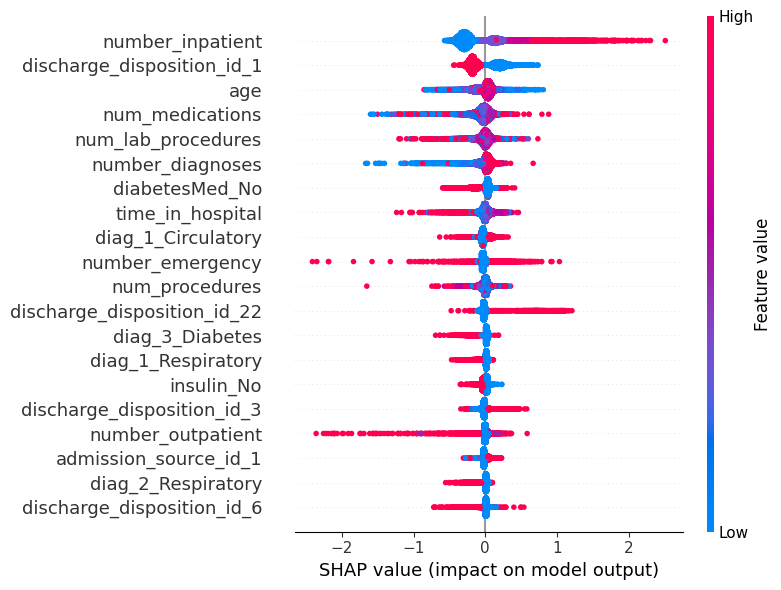

In [235]:
shap.summary_plot(shap_values, X_test, plot_size=(8, 6))

The SHAP global summary plot shows that the model primarily relies on clinically meaningful variables. The number of past inpatient admissions (number_inpatient) is the strongest predictor. This is a clinically expected finding, as patients frequently hospitalized in the past run a higher risk of readmission. Other significant variables—such as age, number of medications, number of lab procedures, length of stay, number of diagnoses, and diagnosis categories (Circulatory, Respiratory, Diabetes), all display clinically logical and interpretable relationships. No suspicious, non-clinical, or potentially biased signals (such as residual IDs or sensitive attributes) were detected among the features deemed most important by the model. This is a positive indicator of the model's reliability, demonstrating that instead of finding 'hidden shortcuts,' the model grounds its decisions on genuine clinical signals.

-----------------------------------------------------------------------------------------------------------------------------------------------------------
SHAP qlobal xülasə qrafiki göstərir ki, model əsasən klinik cəhətdən mənalı dəyişənlərə əsaslanır. Keçmiş stasionar qəbul sayı (number_inpatient) ən güclü proqnozlaşdırıcı amildir. Bu, klinik olaraq gözlənilən bir tapıntıdır (əvvəllər tez-tez xəstəxanaya düşən xəstələrin yenidən qəbul riski daha yüksəkdir). Digər əhəmiyyətli dəyişənlər -  yaş, dərman sayı, laborator test sayı, xəstəxanada qalma müddəti, diaqnoz sayı və diaqnoz kateqoriyaları (Circulatory, Respiratory, Diabetes), hamısı klinik olaraq məntiqli və izah edilə bilən əlaqələr göstərir. Modelin ən vacib hesab etdiyi dəyişənlər arasında heç bir şübhəli, qeyri-klinik və ya potensial qərəzli siqnal (məsələn, ID qalıqları və ya sensitiv atributlar) aşkar edilmədi. Bu, modelin etibarlılığına dair müsbət bir göstəricidir. Model "gizli qısayol" tapmaq əvəzinə, əsl klinik siqnallara əsaslanır.

**Local SHAP**

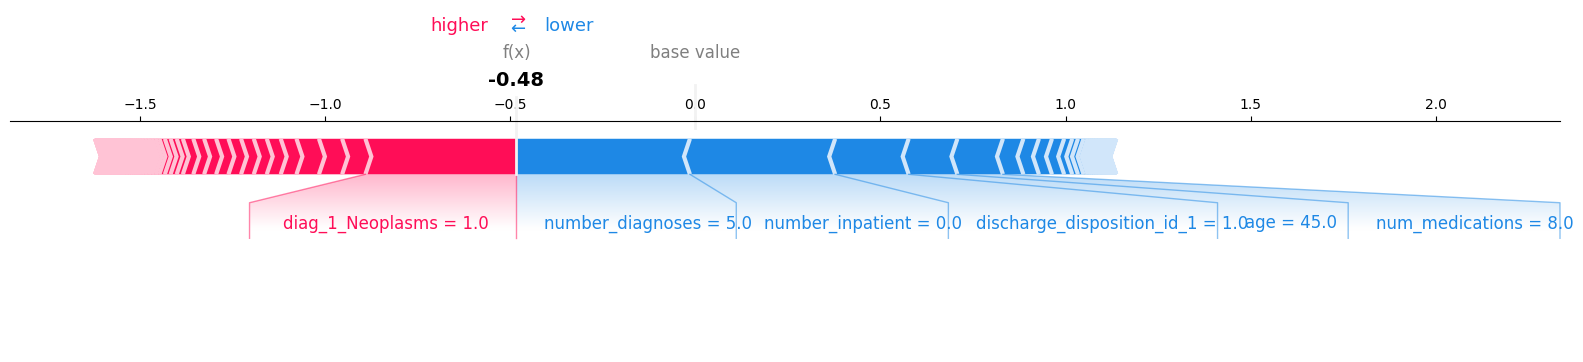

In [236]:
shap.force_plot(explainer.expected_value, shap_values[0], X_test.iloc[0], matplotlib=True)

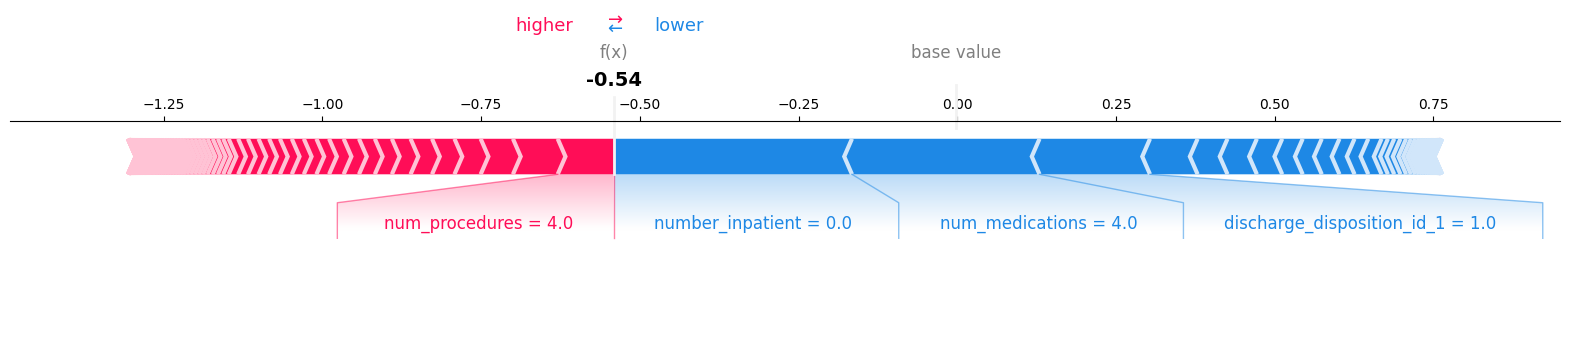

In [237]:
shap.force_plot(explainer.expected_value, shap_values[5], X_test.iloc[5], matplotlib=True)

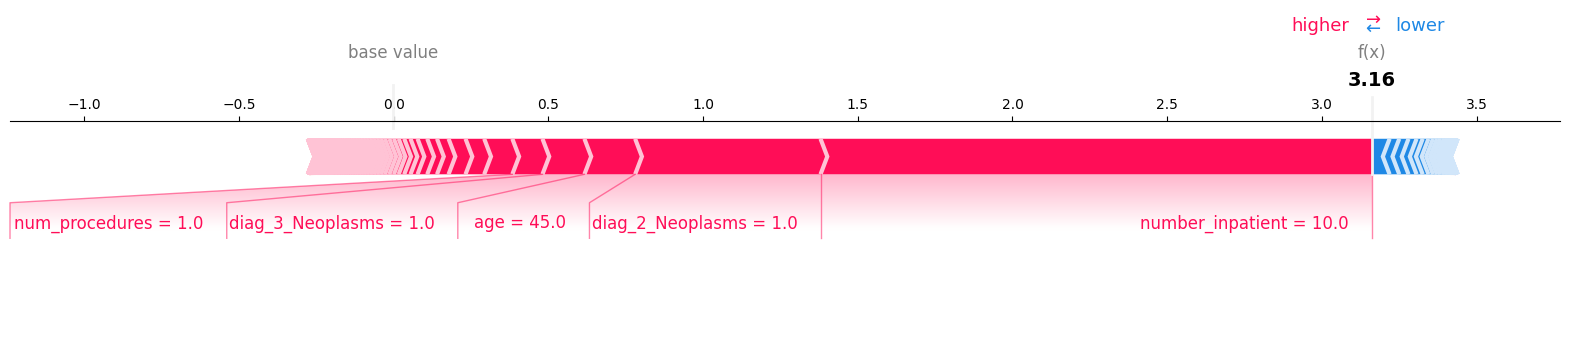

In [238]:
import numpy as np
high_risk_idx = np.argmax(y_proba_xgb)
shap.force_plot(explainer.expected_value, shap_values[high_risk_idx], X_test.iloc[high_risk_idx], matplotlib=True)

Based on the list of risk probabilities generated by the model, we identify and store the index number of the patient with the highest risk. By doing so, we clarify the specific factors that the model deems risky.

-----------------------------------------------------------------------------------------------------------------------------------------------------------
Modelin verdiyi risk ehtimalları siyahısına əsaslanaraq, ən yüksək risk verən pasientin sıra nömrəsini tapıb yadda saxlayırıq. Bununlada, modelin riskili hesab etdiyi məqamların nə olduğunu aydınlaşdırırıq.

**Local SHAP Examples.**

Local SHAP analysis performed for three different patients demonstrated that the model makes consistent and clinically logical decisions:

- For patients predicted to have a low risk (f(x)=-0.48, f(x)=-0.54), the primary driving factor reducing the risk was 'number_inpatient=0'.

- For the patient predicted to have the highest risk (f(x)=3.16), the factor driving up the risk the most was 'number_inpatient=10', with the presence of multiple diagnoses in the 'Neoplasms' category further increasing the risk.

These examples confirm that the model heavily relies on the patient's past hospitalization history and the severity of their diagnoses, delivering clinically interpretable decisions.

-----------------------------------------------------------------------------------------------------------------------------------------------------------
Üç fərqli xəstə üçün aparılan lokal SHAP analizi modelin tutarlı, klinik məntiqli qərarlar verdiyini göstərdi:
- Aşağı risk proqnozlaşdırılan xəstələrdə (f(x)=-0.48, f(x)=-0.54), əsas azaldıcı amil "number_inpatient=0" idi.
- Ən yüksək risk proqnozlaşdırılan xəstədə (f(x)=3.16), riski ən çox artıran amil "number_inpatient=10" oldu, əlavə olaraq bir neçə diaqnozun "Neoplasms" (şiş) kateqoriyasında olması da riski artırdı.

Bu nümunələr, modelin əsasən xəstənin keçmiş xəstəxana müraciət tarixçəsinə və diaqnoz ağırlığına əsaslandığını, klinik cəhətdən izah edilə bilən qərarlar verdiyini təsdiqləyir.